In [126]:
# Importing all required libraries for data analysis,
# visualization and machine learning.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [127]:
# Loading the Iris dataset from Excel file.
# This dataset contains flower measurements.

df = pd.read_excel("../data/iris.xlsx")
print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [128]:
# Displaying the first 5 rows of the dataset
# to understand the structure of the data

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [129]:
# Checking total rows and columns
# present in the dataset.

print("Dataset Shape :", df.shape)

Dataset Shape : (150, 6)


In [130]:
# Displaying all column names
# available in the dataset.

print(df.columns)

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='str')


In [131]:
# Checking dataset information such as
# total rows, columns and datatypes

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [132]:
# Checking if there are any missing values
# in the dataset

df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [133]:
# Displaying statistical summary of the dataset
# of numerical columns

df.describe()


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [134]:
# Counting how many flowers belong
# to each species category

df["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [135]:
# Calculating percentage of flowers
# belonging to each species.

species_percent = (
    df["Species"]
    .value_counts(normalize=True) * 100
)

print(species_percent)

Species
Iris-setosa        33.333333
Iris-versicolor    33.333333
Iris-virginica     33.333333
Name: proportion, dtype: float64


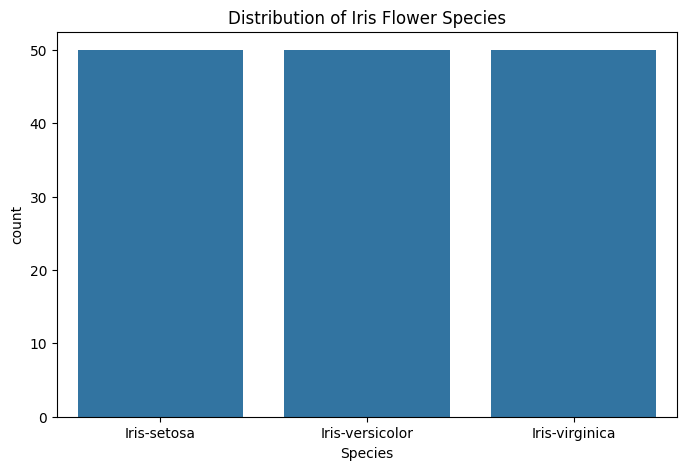

In [136]:
# Visualizing the number of flowers
# in each species category.

plt.figure(figsize=(8,5))

sns.countplot(
    x="Species",
    data=df
)

plt.title("Distribution of Iris Flower Species")

plt.show()

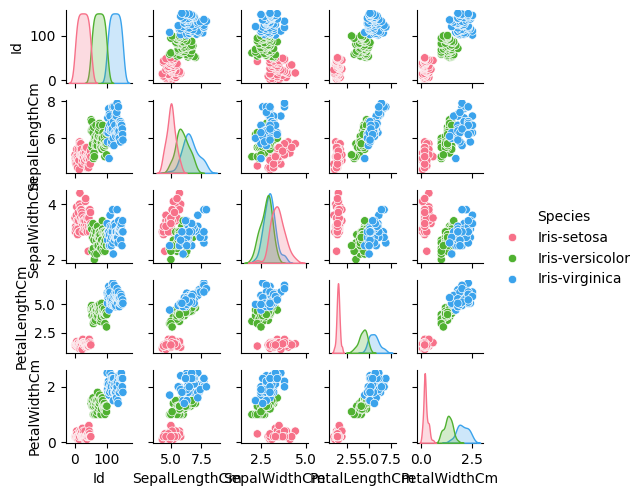

In [137]:
# Creating a pairplot to explore relationships
# between different flower measurements.

sns.pairplot(
    df,
    hue="Species",
    palette="husl",
    height=1,
     
)

plt.show()

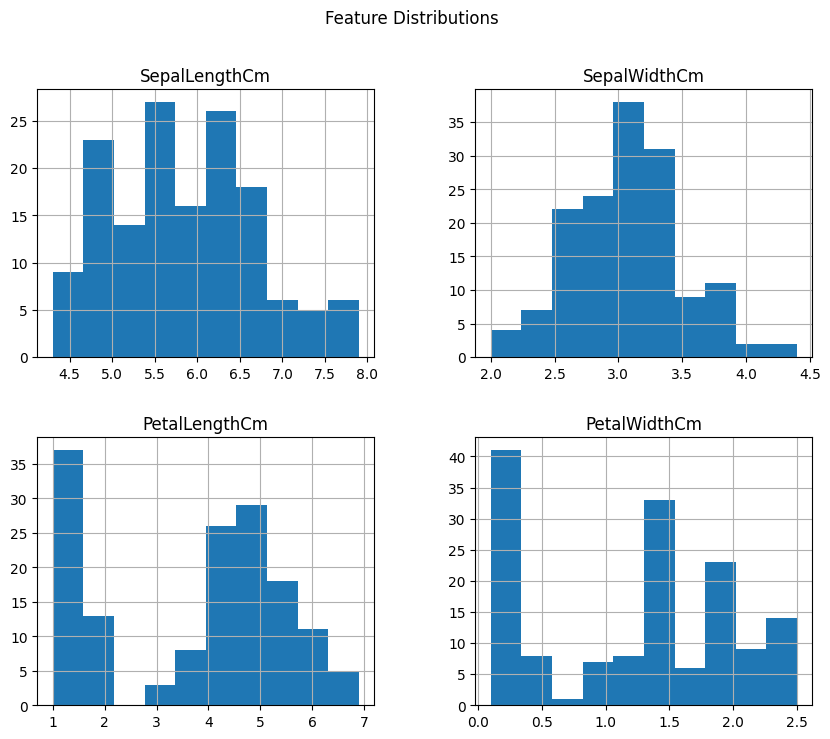

In [138]:
# Visualizing distribution of
# numerical flower measurements.

df.iloc[:,1:5].hist(
    figsize=(10,8)
)

plt.suptitle(
    "Feature Distributions"
)

plt.show()

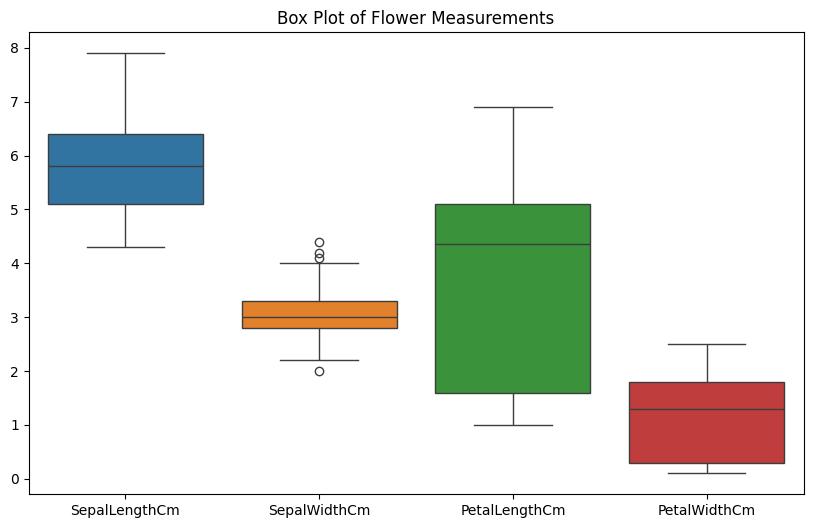

In [139]:
# Visualizing spread of data
# and checking outliers.

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df.iloc[:,1:5]
)

plt.title(
    "Box Plot of Flower Measurements"
)

plt.show()

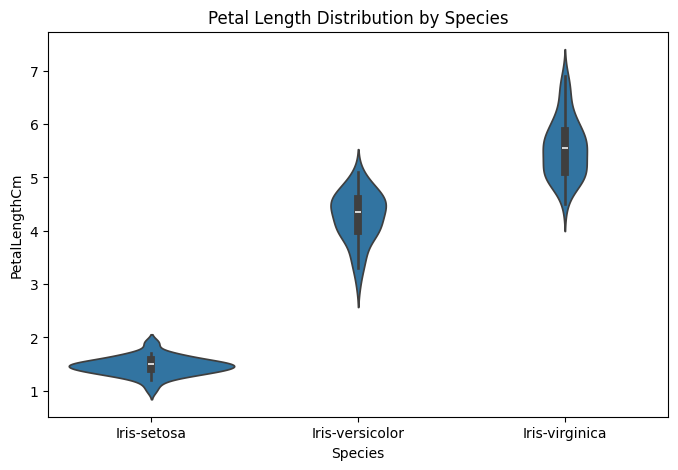

In [140]:
# Comparing petal length across
# different flower species.

plt.figure(figsize=(8,5))

sns.violinplot(
    x="Species",
    y="PetalLengthCm",
    data=df
)

plt.title(
    "Petal Length Distribution by Species"
)

plt.show()

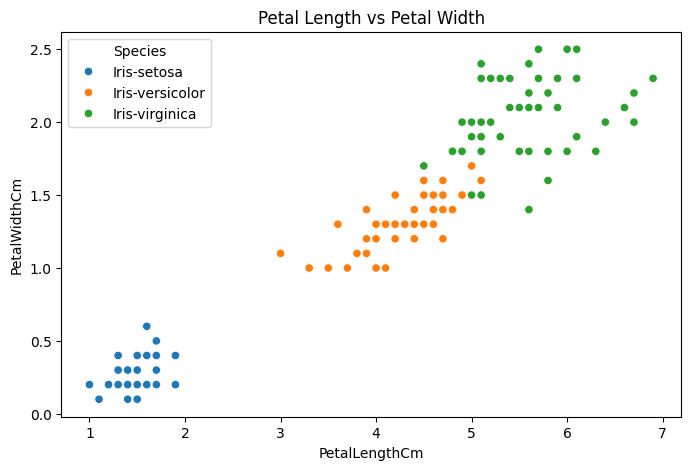

In [141]:
# Comparing petal length and petal width
# using a scatter plot.

plt.figure(figsize=(8,5))

sns.scatterplot(
    x="PetalLengthCm",
    y="PetalWidthCm",
    hue="Species",
    data=df
)

plt.title(
    "Petal Length vs Petal Width"
)

plt.show()

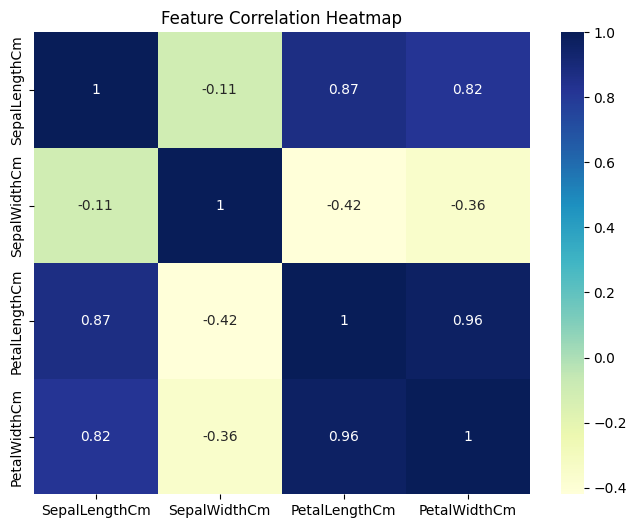

In [142]:
# Creating a heatmap to understand the
# correlation between numerical features.

plt.figure(figsize=(8,6))
sns.heatmap(
    df.iloc[:,1:5].corr(),
    annot=True,
    cmap="YlGnBu",
)
plt.title("Feature Correlation Heatmap")
plt.show()

In [143]:
# Calculating average measurements
# for each flower species.

df.groupby("Species").mean()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
Species,,,,,
Iris-setosa,25.5,5.006,3.418,1.464,0.244
Iris-versicolor,75.5,5.936,2.770,4.260,1.326
Iris-virginica,125.5,6.588,2.974,5.552,2.026


In [144]:
# Selecting input features and target variable.
# X contains flower measurements and y contains species names.

X = df.iloc[:, 1:5]

y = df.iloc[:, 5]

In [145]:
# Selecting input features and
# target variable.

X = df[
    [
        "SepalLengthCm",
        "SepalWidthCm",
        "PetalLengthCm",
        "PetalWidthCm"
    ]
]

y = df["Species"]

In [146]:
# Splitting dataset into training and testing data.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [147]:
# Creating K-Nearest Neighbors classification model.

model = KNeighborsClassifier(
    n_neighbors=3
)

In [148]:
# Training the machine learning model.
# The model learns patterns from training data.

model.fit(
    X_train,
    y_train
)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [149]:
# Predicting flower species using test data.
# The trained model predicts unseen samples.

y_pred = model.predict(
    X_test
)

In [150]:
# Calculating model accuracy score.
# Accuracy shows how many predictions were correct.

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    f"Model Accuracy : {accuracy*100:.2f}%"
)

Model Accuracy : 100.00%


In [151]:
# Creating confusion matrix to compare
# actual and predicted values.

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [152]:
print(y[:5])

0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: Species, dtype: str


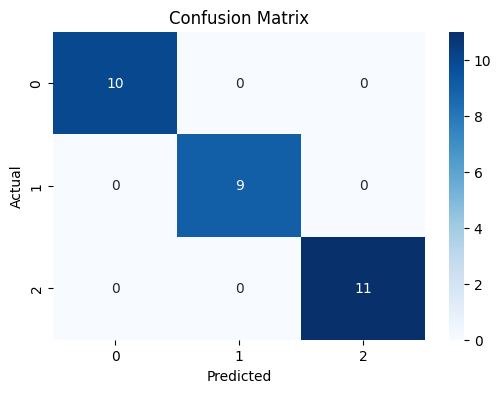

In [153]:
# Visualizing confusion matrix.

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "Confusion Matrix"
)

plt.show()

In [154]:
# Displaying classification report to check
# precision, recall and f1-score

print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [155]:
# Testing model on a custom flower sample.

sample = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=X.columns
)

prediction = model.predict(
    sample
)

print(
    "Predicted Flower Species:",
    prediction[0]
)

Predicted Flower Species: Iris-setosa


In [156]:
sample = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=X.columns
)

prediction = model.predict(sample)

print(
    "Predicted Flower Species:",
    prediction[0]
)

Predicted Flower Species: Iris-setosa


In [157]:
# Displaying final project summary.

print("="*50)
print("IRIS FLOWER CLASSIFICATION PROJECT")
print("="*50)

print(f"Dataset Shape : {df.shape}")
print(f"Algorithm     : KNN")
print(f"Accuracy      : {accuracy*100:.2f}%")

print("="*50)
print("Project Completed Successfully")
print("="*50)

IRIS FLOWER CLASSIFICATION PROJECT
Dataset Shape : (150, 6)
Algorithm     : KNN
Accuracy      : 100.00%
Project Completed Successfully
